In [13]:
# import matplotlib.pyplot as plt
# import numpy as np


In [14]:
# #test np.eye
# # for N = 100

# #



# #ws = xs + ys + zs

# #print(ws)

# N = 5 # dimension
# mass = 1
# hbar = 1
# omega = 0.8

# x_pos = np.zeros(N) # from -N/2 to N/2

# for i in range(N):
#     x_pos[i] = i-N/2

# potential_array = np.zeros(N) # from -N/2 to N/2, x^2

# for i in range(N):
#     potential_array[i] = 0.5*mass*(omega**2)*(i-N/2)**2



# def hamiltonian(x_pos, potential_array, mass):
#     dim = x_pos.shape[0]
    
#     xs = np.eye(dim, dim, k=-1)
#     ys = np.eye(dim, dim, k=1)
#     zs = -2*np.eye(dim, dim, k=0)

#     Ts = xs + ys + zs
#     Vs = np.zeros((dim, dim))

#     for i in range(dim):
#         Vs[i,i] = potential_array[i]

#     Hs = Ts + Vs

#     return    Hs

# print(hamiltonian(x_pos, potential_array, mass))


# ms = lin.eigh(hamiltonian(x_pos, potential_array, mass))

# print(ms[0])
# ps = ms[1]


# fig, ax1 = plt.subplots()
# ax1.plot(x_pos, ps[6])
# ax1.plot(x_pos, (x_pos)**2)


In [15]:
# def hamiltonian(x_pos, potential_array, mass, hbar, dx):
#     dim = x_pos.shape[0]
    
#     xs = np.eye(dim, dim, k=-1)
#     ys = np.eye(dim, dim, k=1)
#     zs = -2*np.eye(dim, dim, k=0)

#     Ts = xs + ys + zs
#     Vs = np.zeros((dim, dim))

#     for i in range(dim):
#         Vs[i,i] = potential_array[i]

#     Hs = -(Ts)*(hbar**2)/(2*mass*(dx**2)) + (Vs)

#     return    Hs

In [16]:
# import matplotlib.pyplot as plt
# import numpy as np

# m = 1
# w = 0.8
# hbar = 1

# length = 8

# dpoints = 300


# x_pos = np.linspace(-0.5*length, 0.5*length, num = dpoints)

# dx = x_pos[2] - x_pos[1]

# x_potential_temp = np.zeros(dpoints)

# for i in range(dpoints):
#     x_potential_temp[i] = 0.5*m*(w**2)*(x_pos[i])**2

# x_potential = x_potential_temp.copy()


# Vs_temp = np.zeros((dpoints, dpoints))

# for i in range(dpoints):
#         Vs_temp[i,i] = x_potential[i]

# Vs = Vs_temp.copy()

# def hamiltonian(dpoints, Vs, hbar, m ,dx):

#     xs = np.eye(dpoints, dpoints, 1)
#     ys = -2*np.eye(dpoints, dpoints, 0)
#     zs = np.eye(dpoints, dpoints, -1)
#     Ts = -(xs + ys + zs)*(hbar**2)/(2*m*(dx**2))

#     Hs =  Ts + Vs
    
#     return Hs

# es = np.linalg.eigh(hamiltonian(dpoints, Vs, hbar, m ,dx))


# evals = es[0]
# evecs = es[1]

In [17]:
# fig, ax1 = plt.subplots()


# ax1.plot(x_pos, evecs[:,0])
# ax1.plot(x_pos, 0.01*x_potential)

In [18]:
# length = 6
# dpoints = 300

# x_position = np.linspace(-0.5*length, 0.5*length, dpoints)
# diffx = x_position[1] - x_position[0]

# xs = np.eye(dpoints, dpoints, 1)
# ys = -2*np.eye(dpoints, dpoints, 0)
# zs = np.eye(dpoints, dpoints, -1)

# Ts = -(xs + ys + zs)/(2*(diffx**2))


# x_potential_at = np.zeros(dpoints)

# for i in range(dpoints):
#     x_potential_at[i] = (x_position[i])**2

# Vs = np.zeros((dpoints, dpoints))

# for i in range(dpoints):
#     Vs[i,i] = x_potential_at[i]

# me_eval, me_evec = np.linalg.eigh(Vs+Ts)


# column = me_evec[:,0]
# plt.plot(x_position, column)



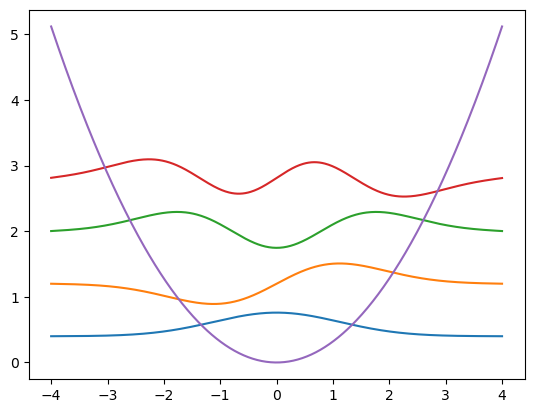

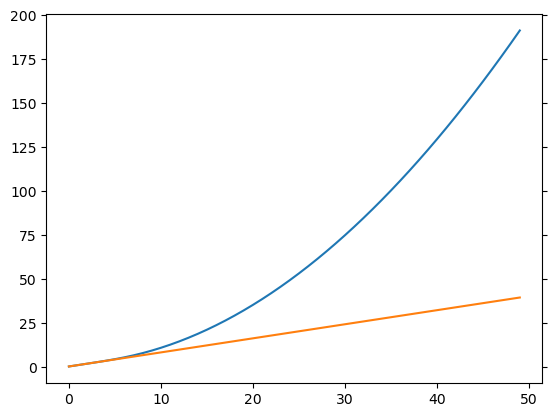

In [19]:
import matplotlib.pyplot as plt
import numpy as np


extent = 8
dpoints = 500
mass = 1
w = 0.8
hbar = 1

x_position = np.linspace(-0.5*extent, 0.5*extent, num = dpoints)

x_qho_pot = np.zeros(dpoints)
for i in range(dpoints):
    x_qho_pot[i] = 0.5*mass*(w**2)*(x_position[i]**2)

def hermitian(x_position, x_qho_pot, hbar, mass):
    dim = x_position.shape[0]
    dx = x_position[1] - x_position[0]
    
    xs = np.eye(dim, dim, -1)
    ys = -2*np.eye(dim, dim, 0)
    zs = np.eye(dim, dim, 1)

    Ts = -(xs + ys + zs)*(hbar**2)/(2*mass*(dx**2))

    Vs = np.zeros((dim, dim))

    for i in range(dim):
        Vs[i,i] = x_qho_pot[i]

    Hs = Ts + Vs

    return Hs

evals, evecs = np.linalg.eigh(hermitian(x_position, x_qho_pot, hbar, mass))

fig, ax = plt.subplots()
for i in range(4):
    scaling = 4
    ax.plot(x_position, evals[i] + scaling*(evecs[:,i]))
ax.plot(x_position, x_qho_pot)

fig2, ax2 = plt.subplots()
x_ax = np.array(range(50))

ax2.plot(x_ax, evals[:50])
ax2.plot(x_ax, hbar*w*(x_ax + 0.5))
ax2.tick_params(right="true")


(-1.0, 8.0)

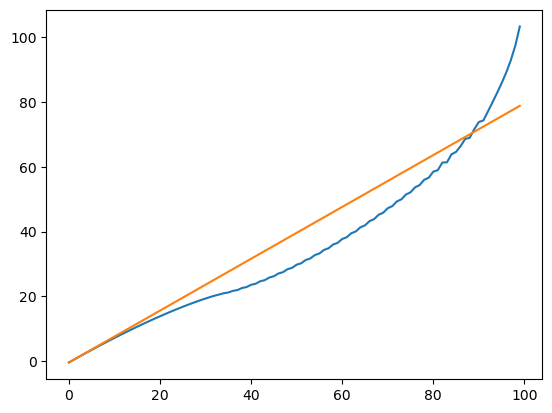

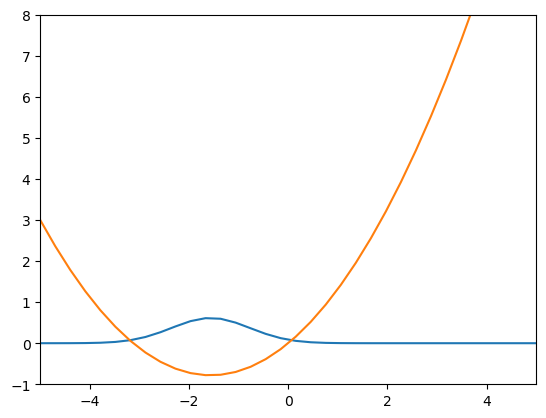

In [23]:
import matplotlib.pyplot as plt
import numpy as np


extent = 30
dpoints = 100

mass = 1
w = 0.8
hbar = 1

x_position = np.linspace(-0.5*extent, 0.5*extent, num = dpoints)

x_electric_pot = np.zeros(dpoints)
for i in range(dpoints):
    x_electric_pot[i] = 0.5*mass*(w**2)*(x_position[i]**2) + x_position[i]

def hermitian(x_position, x_qho_pot, hbar, mass):
    dim = x_position.shape[0]
    dx = x_position[1] - x_position[0]
    
    xs = np.eye(dim, dim, -1)
    ys = -2*np.eye(dim, dim, 0)
    zs = np.eye(dim, dim, 1)

    Ts = -(xs + ys + zs)*(hbar**2)/(2*mass*(dx**2))

    Vs = np.zeros((dim, dim))

    for i in range(dim):
        Vs[i,i] = x_qho_pot[i]

    Hs = Ts + Vs

    return Hs

evals, evecsn = np.linalg.eigh(hermitian(x_position, x_electric_pot, hbar, mass))




fig, ax= plt.subplots()

x_ax = np.array(range(100))
theoretical = hbar*w*(x_ax + 0.5) - 1/(2*mass*w**2)

ax.plot(x_ax, evals[:100])
ax.plot(x_ax, theoretical)

fig2, ax2 = plt.subplots()

ax2.plot(x_position, 4*evecsn[:,0]**2)
ax2.plot(x_position, x_electric_pot)
ax2.set_xlim(-5,5)
ax2.set_ylim(-1,8)